### Упражнение 1

- Объедините (сложите) [синус, тренд и шум](#сигнал-с-трендом-и-шумом), которые мы определили ранее, и получите сигнал, состоящий из:
* Синусоидальной волны, представляющей сезонность.
* Параболической функции, представляющей тренд.
* и равномерно распределенного случайного шума.
- Постройте графики компонентов временной и частотной областей.
- Измените амплитуду компонентов синуса, тренда и шума так, чтобы каждый компонент, в свою очередь, доминировал над другими. Прокомментируйте, как изменяется FT общего сигнала.
- Измените синус в сигнал, который является суммой 2 синусоидальных волн разной амплитуды на 1 и 10 Гц, а также постоянного члена. Постройте графики во временной и частотной областях и прокомментируйте результаты.

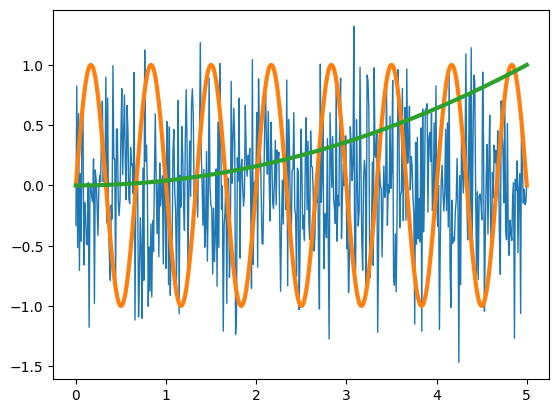

In [34]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 5, 512)
freq = 1.5

y_sine = np.sin(2 * np.pi * freq * time)
y_trend = (0.2 * time)**2
y_noise = 0.5 * np.random.randn(len(time))
plt.plot(time,y_noise,linewidth=1)
plt.plot(time,y_sine,linewidth=3)
plt.plot(time,y_trend,linewidth=3)

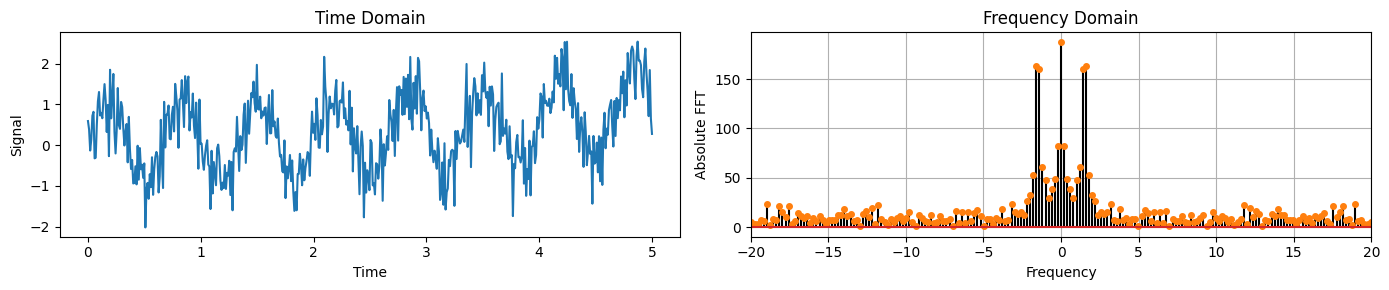

In [24]:
def plot_time_freq(t, y):
    # Converts Data into Frequncy Domain
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))

    # Time domain plot
    plt.figure(figsize = [14,3])
    plt.subplot(1,2,1)
    plt.plot(t,y)
    plt.title('Time Domain')
    plt.xlabel('Time')
    plt.ylabel('Signal')

    # Frequency domain plot
    plt.subplot(1,2,2)
    markerline, stemline, baseline = plt.stem(np.fft.fftshift(freq),np.fft.fftshift(Y),
                                              'k', markerfmt='tab:orange')
    plt.setp(stemline, linewidth = 1.5)
    plt.setp(markerline, markersize = 4)
    plt.title('Frequency Domain')
    plt.xlabel('Frequency')
    plt.xlim(-20, 20)
    plt.ylabel('Absolute FFT')
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_time_freq(time,y_sine+y_trend+y_noise)

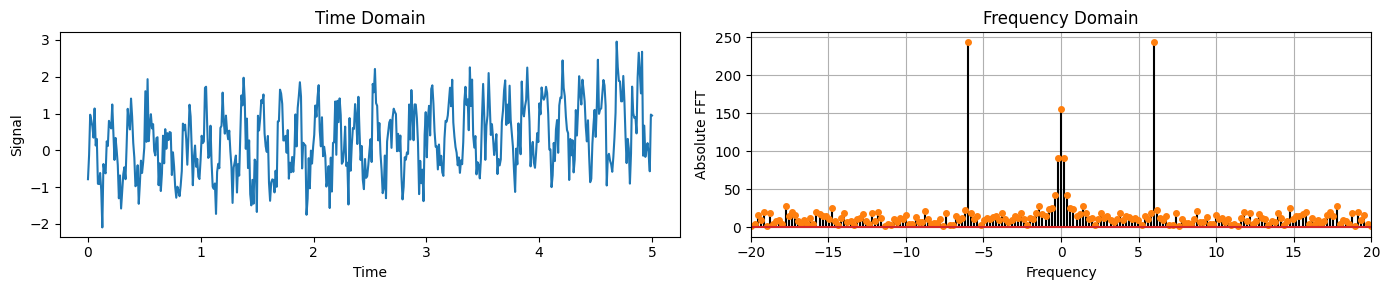

In [ ]:
# Теперь у нас главные частоты сместились с около +-2 на около +-8
y_sine = np.sin(8 * np.pi * freq * time)
y_trend = (0.2 * time)**2
y_noise = 0.5 * np.random.randn(len(time))
plot_time_freq(time,y_sine+y_trend+y_noise)

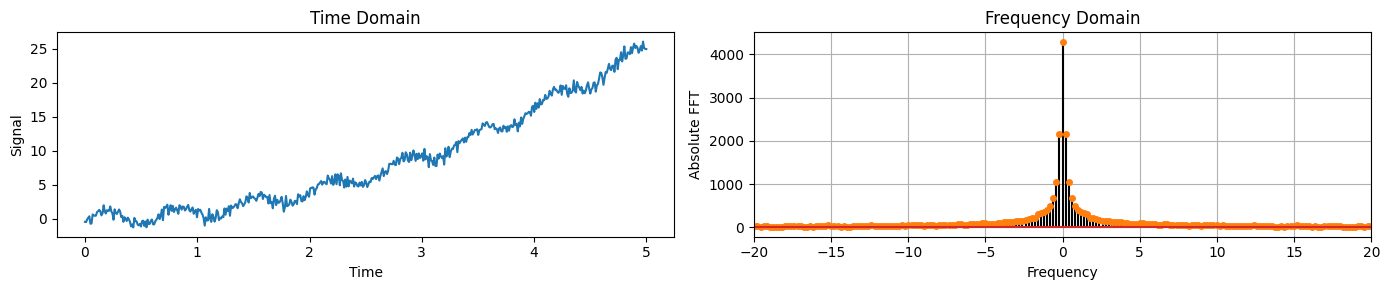

In [ ]:
# теперь у нас сигнал стал ближе к константе, монотонно возрастает, поэтому
# fft среагировал как на константу
y_sine = np.sin(2 * np.pi * freq * time)
y_trend = (1 * time)**2
y_noise = 0.5 * np.random.randn(len(time))
plot_time_freq(time,y_sine+y_trend+y_noise)

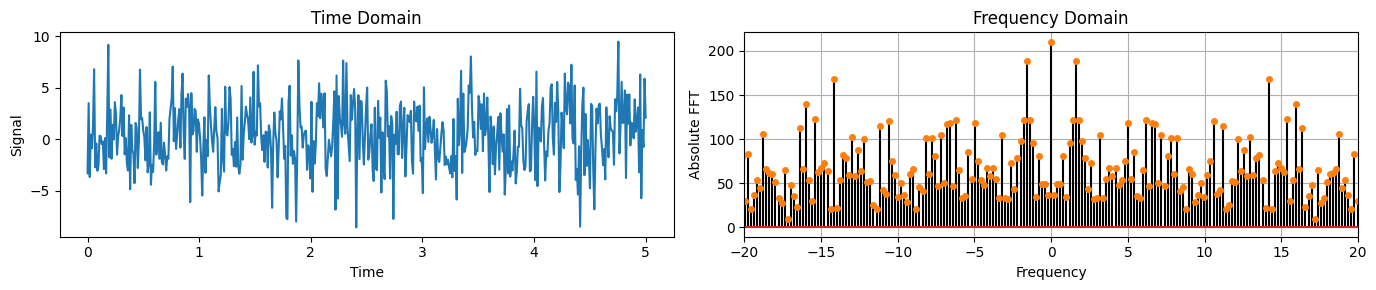

In [ ]:
# теперь у нас сигнал стал ближе к шуму, и fft теперь выдает +- нормально распределение по частотам.
y_sine = np.sin(2 * np.pi * freq * time)
y_trend = (0.2 * time)**2
y_noise = 3 * np.random.randn(len(time))
plot_time_freq(time,y_sine+y_trend+y_noise)

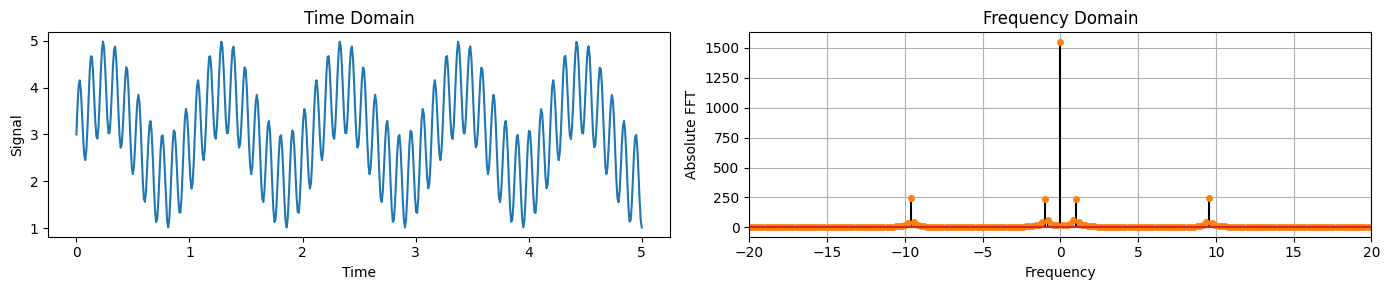

In [ ]:
# построим сигнал на 1 и 10 герц и константой
# теперь у нас ожидаемо fft стала дельта функцией от константы, и в точках +-10 +-1 у нас пики
y_sine = np.sin(4 * freq * time)+np.sin(40* freq * time)
y_const = 3
plot_time_freq(time,y_sine+y_const)